# Load required packages

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [27]:
# load epilepsy dataset 
epilepsy = pd.read_csv("./Datasets/EpilepsyCleaned.csv", sep= ',', decimal= '.', on_bad_lines = 'error', skip_blank_lines=False)

# load dementia dataset 
dementia = pd.read_csv("./Datasets/DementiaCleaned.csv", sep= ',', decimal= '.', on_bad_lines = 'error', skip_blank_lines=False)

# Check Data Load is correct

In [28]:
pd.set_option('display.max_columns', None)

In [29]:
epilepsy.head()

,Age,Gender,Weight,Height,Medication Status,Alcohol or Drug Use,EEG Abnormality Detected,MRI/CT Scan Result,Seizure Frequency,Seizure Duration,Seizure Type,Aura Before Seizure,Loss of Consciousness,Muscle Stiffness,Jerky Movements,Postictal Confusion,Blank Stare Episodes,Eye Rolling,Stress or Anxiety Before Episode,Lack of Sleep Before Episode,Flashing Lights Sensitivity,Loud Sound Sensitivity,Missed Medication,Family History of Epilepsy,Head Injury History,Brain Tumor,History of Stroke,Genetic Disorder,Developmental Delay (in Children),Epilepsy Type
0,15,Male,48.3,168.2,On Medication,Yes,Yes,Normal,1,60,Tonic-Clonic,No,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,No,No,No,No,Yes,Generalised
1,36,Female,44.8,156.2,On Medication,No,Yes,Abnormal,3,30,Tonic-Clonic,Yes,No,Yes,Yes,No,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,No,No,No,Generalised
2,32,Female,70.4,180.4,Not on Medication,No,Yes,Not Done,0,60,Focal,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,No,No,No,No,No,No,Focal
3,29,Male,54.5,161.7,On Medication,No,Yes,Not Done,1,60,Tonic-Clonic,No,Yes,Yes,Yes,Yes,No,No,Yes,No,No,Yes,No,Yes,No,Yes,No,No,No,Generalised
4,18,Male,62.1,168.0,On Medication,No,Yes,Abnormal,1,30,Tonic-Clonic,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,Yes,No,No,No,No,No,Generalised


In [30]:
pd.reset_option('display.max_columns')

# Epilepsy Dataset 

## Weight, Height, and Age per Epilepsy type

Text(0.5, 0.98, 'Weight, Height, Age Distribution per epilepsy type')

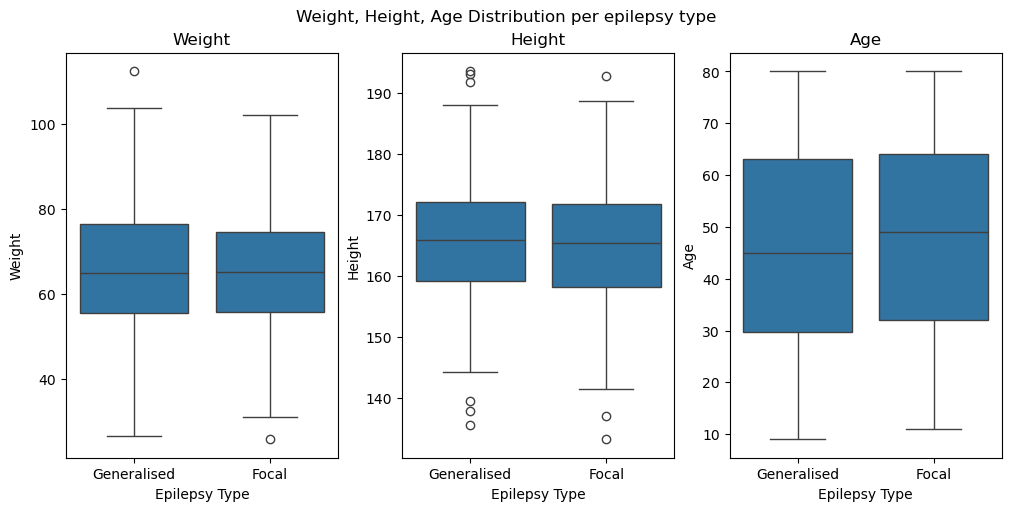

In [64]:
fig = plt.figure(figsize=(10,5), constrained_layout=True)
axs = fig.subplots(1, 3) 

target_vars = ["Weight", "Height", "Age"]

for i, var in enumerate(target_vars):
    sns.boxplot(data=epilepsy, x="Epilepsy Type", y=var, ax=axs[i])
    axs[i].set_title(var)
    

fig.suptitle('Weight, Height, Age Distribution per epilepsy type')

The boxplots above shows the distribution of variables Age, Weight and Height per epilepsy type. We can observe that the distribution is similar between Generalised and Focal. There are a few outliers in both Weight and Height. However, this was discussed and concluded that they are valid values in the (data cleaning section for impossible values). This shows that these three variables are not useful indicators to distinguish between between classes or epilepsy type.  

## Seizure Frequency and Duration

Text(0.5, 0.98, 'Seizure Frequency and Seizure Duration per epilepsy type')

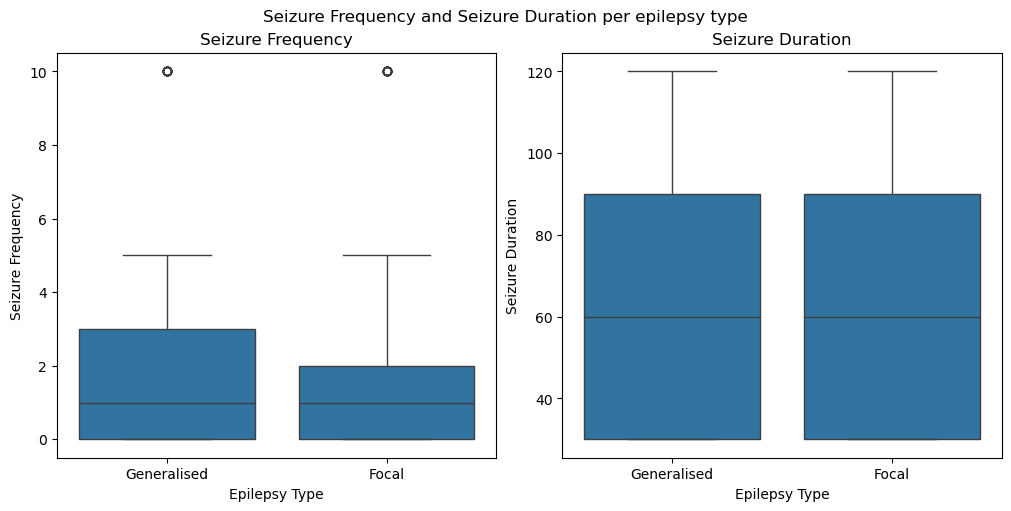

In [201]:
fig = plt.figure(figsize=(10,5), constrained_layout=True)
axs = fig.subplots(1, 2) 

target_vars = ['Seizure Frequency', 'Seizure Duration']

for i, var in enumerate(target_vars):
    sns.boxplot(data=epilepsy, x="Epilepsy Type", y=var, ax=axs[i])
    axs[i].set_title(var)
    

fig.suptitle('Seizure Frequency and Seizure Duration per epilepsy type')

From the boxplots above, we can see that the distribution of seizure duration is very similar. However for seizure frequency, bulk of the data is on the lower end. Generalised has more patients with slightly higher seizure frequency. This could potentially be a distinguishable feature. 

## Explore binary columns (Yes/No) to distinguish between Epilepsy Type

The features that are explored below are categorical variables with values 'Yes' and 'No'. As different epilepsy type have different symptoms, these variable may help machine learning models to distinguish between types. To find features that may distinguish epilepsy type, bar charts are used to show percentages of 'Yes'es within each epilepsy type. First we will group the variables in epilepsy type, count the number of 'Yes'es and find its percentage.

Function below plots 5 subplots with one variable in each. 

In [193]:
def plot_five(five_vars):
    fig = plt.figure(figsize=(10,3), constrained_layout=True)
    axs = fig.subplots(1, 5) 
    
    for i, feature in enumerate(features): 
        # calculate the percentages of "Yes" for each Epilepsy Type - rmb: after grouping, apply works on group 
        # (x == 'Yes') returns a series of True and False / 0 or 1, using mean() get the percentage of yeses within each var 
        yes_percentages = epilepsy.groupby('Epilepsy Type')[feature].apply(lambda x: (x == 'Yes').mean() * 100).reset_index(name='percentage')
        
        ax = axs[i]
        sns.barplot(data=yes_percentages, x='Epilepsy Type', y='percentage', ax=ax)

        # some edge cases to prevent title from overlapping
        if(feature == 'Stress or Anxiety Before Episode'):
            feature = 'Stress or Anxiety \nBefore Episode'
        elif(feature == 'Lack of Sleep Before Episode'): 
            feature = 'Lack of Sleep \nBefore Episode'
        elif(feature == 'Developmental Delay (in Children)'):
            feature = 'Developmental Delay \n(in Children)'
        elif(feature == 'EEG Abnormality Detected'):
            feature = 'EEG Abnormality \nDetected'
        
        ax.set_title(feature.lower())
        ax.tick_params(axis = 'x', labelsize = 10)
        ax.set_xlabel('Epilepsy Type', fontsize=7)
        
    fig.suptitle('Yes percentages within each Epilepsy Type', fontsize=13)

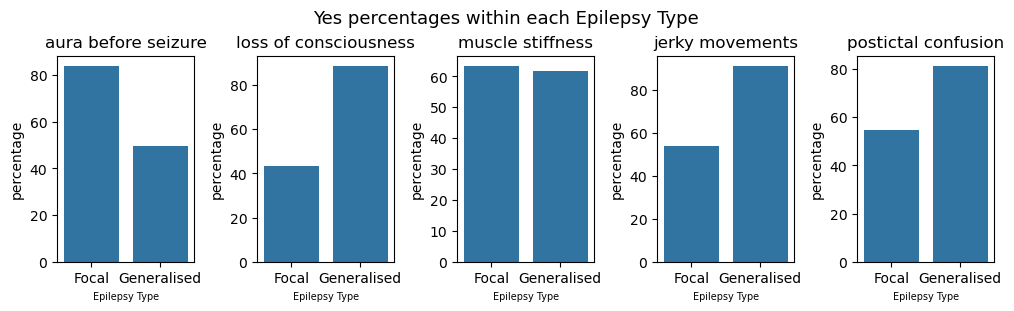

In [194]:
features = ['Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness', 'Jerky Movements', 'Postictal Confusion']
plot_five(features)

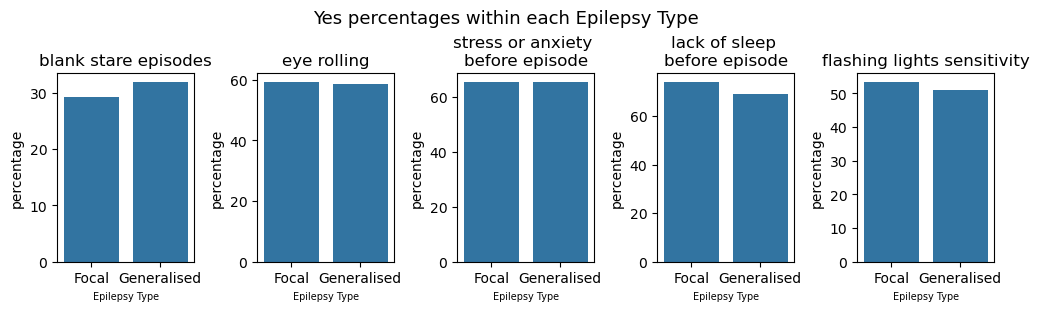

In [195]:
features = ['Blank Stare Episodes', 'Eye Rolling', 'Stress or Anxiety Before Episode', 'Lack of Sleep Before Episode', 'Flashing Lights Sensitivity']
plot_five(features)

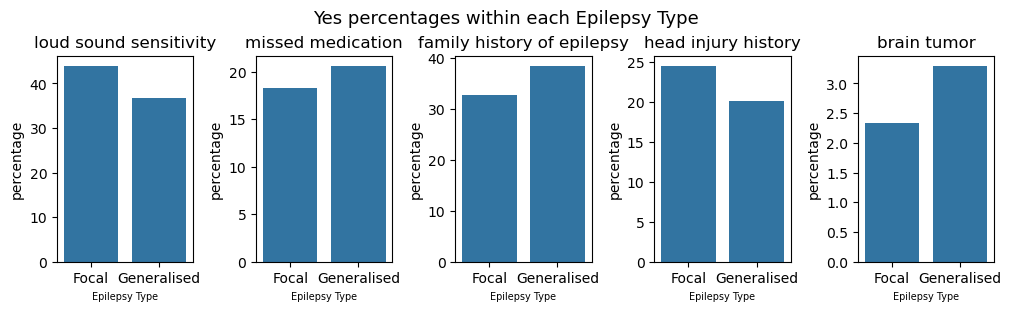

In [196]:
features = ['Loud Sound Sensitivity', 'Missed Medication', 'Family History of Epilepsy', 'Head Injury History', 'Brain Tumor']
plot_five(features)

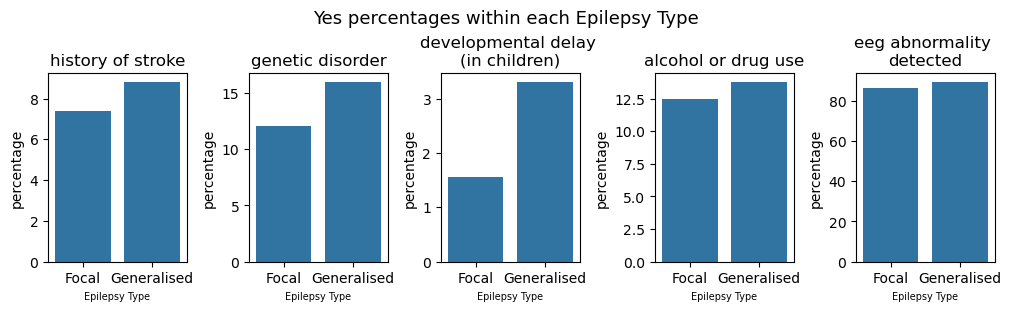

In [197]:
features = ['History of Stroke', 'Genetic Disorder', 'Developmental Delay (in Children)', 'Alcohol or Drug Use', 'EEG Abnormality Detected']
plot_five(features)

## Variables with larger differences in Yes percentage

From the plots above, variables with larger differences in percentages are 'Loss of Consciousness', 'Jerky Movements', 'Developmental Delay (in Children)', 'Aura Before Seizure'. Their plots can be found below. 

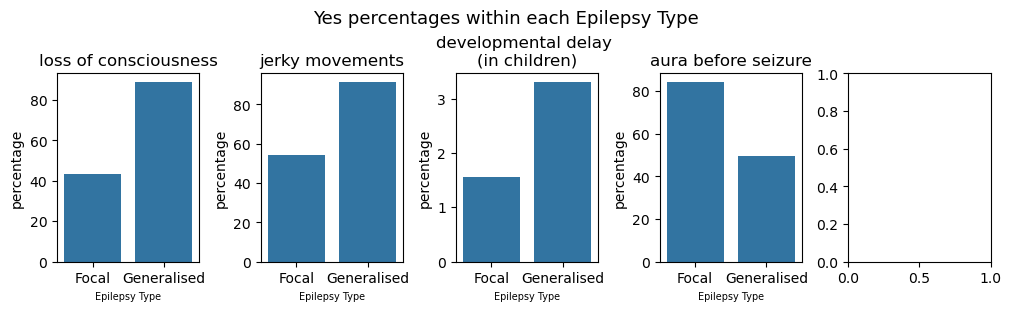

In [198]:
features = ['Loss of Consciousness', 'Jerky Movements', 'Developmental Delay (in Children)', 'Aura Before Seizure']
plot_five(features)

These variables will be discussed here: 
1. Loss of Conciousness, this variable indicates whether if conciousness is lost during a seizure. Focal has 40% and Generalised has around 90%.
2. Jerkey Movements, this variable indicates any rhythmic body movements during seizure. Focal has around 50% and Generalised has around 90%.

We can clearly see that patients that are categorised as Generalised has a much higher percentage in having these symptomps.

3. Developmental Delay, the percentages for this variable very low. Hence, it will not be explored for this section.
4. Aura before Seizure, this variable indicates whether presence of sensory warning signs before a seizure. This includes sparkling lights or blurry vision. Focal has around 90% and Generalised has around 50%. This is a good indicator as Focal type is known for having aura [1]. 

Even though most of the variables have similar percentages, the machine learning model such as decision tree will take the different combinations of these variables into account. 

- [1] https://www.epilepsy.com/what-is-epilepsy/seizure-types

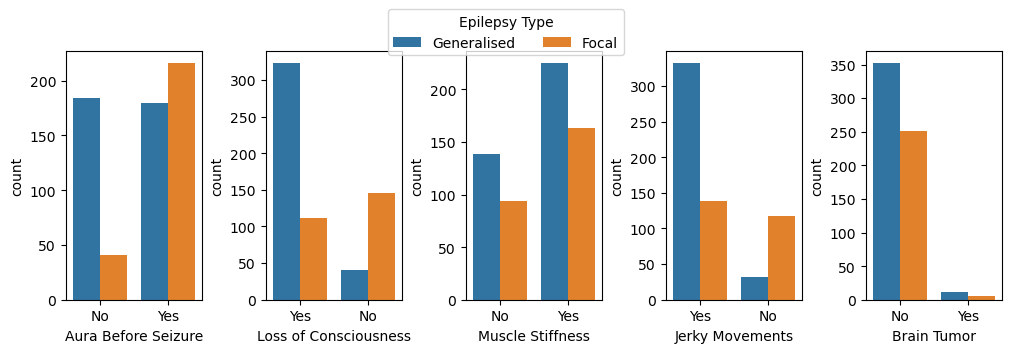

In [171]:
features = ['Aura Before Seizure', 'Loss of Consciousness', 'Muscle Stiffness', 'Jerky Movements', 'Brain Tumor']

fig = plt.figure(figsize=(10,3), constrained_layout=True)
axs = fig.subplots(1, 5) 

for i, feature in enumerate(features): 
    ax = axs[i]
    # sns.countplot(data=epilepsy[epilepsy[feature] == 'Yes'], x=feature, hue="Epilepsy Type", ax=axs[i])
    sns.countplot(data=epilepsy, x=feature, hue="Epilepsy Type", ax=axs[i])
    # ax.set_ylabel('Density', fontsize = 10)

    # ax.set_xlabel(epitype.lower(), fontsize = 10)
    # ax.tick_params(axis = 'x', labelsize = 10)
    # ax.tick_params(axis = 'y', labelsize = 10)

    handles, labels = axs[i].get_legend_handles_labels()
    
    # Remove the subplot legend
    if axs[i].get_legend() is not None:
        axs[i].get_legend().remove()
    
# Add one shared legend to the figure
fig.legend(handles, labels, title="Epilepsy Type", loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=len(labels))


In [66]:
pd.crosstab(epilepsy['Seizure Type'], epilepsy['Epilepsy Type'])

Epilepsy Type,Focal,Generalised
Seizure Type,,
Absence,9,6
Focal,215,17
Generalized,20,227
Tonic-Clonic,13,114


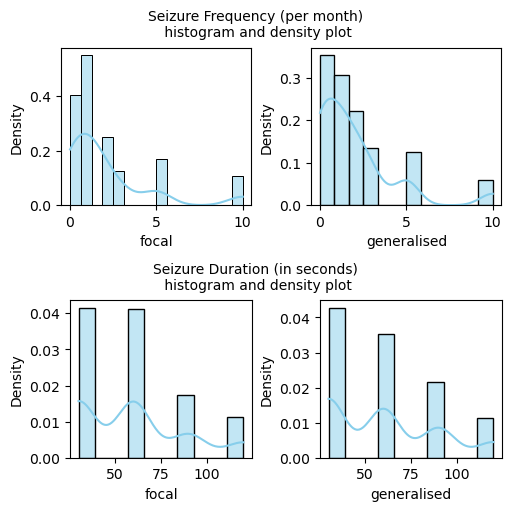

In [199]:
fig = plt.figure(figsize=(5, 5), constrained_layout=True)
subfigs = fig.subfigures(2, 1)
feature = ['Seizure Frequency', 'Seizure Duration']
title = [f'Seizure Frequency (per month)\n histogram and density plot', f'Seizure Duration (in seconds)\n histogram and density plot']

for j, subfig in enumerate(subfigs):
    subfig.suptitle(title[j], fontsize = 10)
    axs = subfig.subplots(1, 2) 
    
    for i, epitype in enumerate(['Focal', 'Generalised']): 
        ax = axs[i]
        
        target_data = epilepsy[epilepsy['Epilepsy Type'] == epitype]
        sns.histplot(target_data[feature[j]], kde=True, stat="density", color="skyblue", ax=ax)
        ax.set_ylabel('Density', fontsize = 10)
        
        ax.set_xlabel(epitype.lower(), fontsize = 10)
        ax.tick_params(axis = 'x', labelsize = 10)
        ax.tick_params(axis = 'y', labelsize = 10)
            